# <span style="color:teal"> Lezione 6 </span>
### L'algoritmo di Metropolis
L'algoritmo di Metropolis $M(RT)^2$ è una tecnica di campionamento Monte Carlo basata sulla simulazione di una catena di Markov. L'idea centrale è costruire una dinamica stocastica la cui distribuzione stazionaria coincida con la distribuzione target $p(x)$, senza necessità di conoscerne la normalizzazione.

Ad ogni passo, a partire dallo stato corrente $x_n$, si propone uno stato candidato $x'$ campionato da una distribuzione di prova $T(x'|x_n)$, che viene accettato con probabilità:

$$A(x'|x) = \min\left[1,\, \frac{p(x')}{p(x)}\right]$$
dove si è assunto $T(x'|x) = T(x|x')$. La mossa viene quindi sempre accettata se la probabilità diventa maggiore, mentre solo probabilisticamente altrimenti. Questa scelta garantisce che $p(x)$ sia la distribuzione invariante della catena, poiché soddisfa il *bilancio dettagliato*. Ripetendo il procedimento un numero sufficiente di volte, i campioni generati si distribuiscono secondo $p(x)$ una volta superato il transitorio iniziale, detto *tempo di equilibrazione*.

### Il campionamento di Gibbs
Il campionamento di Gibbs, è un caso particolare del Metropolis in cui la mossa proposta viene sempre accettata. Invece di proporre una mossa globale e decidere se accettarla, si aggiorna una variabile alla volta campionandola direttamente dalla sua distribuzione condizionata a tutte le altre variabili fissate.

Dato uno stato corrente $\{x_1, x_2, ..., x_n\}$, ad ogni passo si seleziona una componente $x_k$ e si rimpiazza il suo valore con uno campionato da:
$$p(x_k \mid x_j,\, j \neq k)$$
ovvero la distribuzione condizionata di $x_k$ dato il valore attuale di tutte le altre componenti. Dopodiché si passa alla componente successiva, e così via ciclicamente.

Il motivo per cui la mossa è sempre accettata si vede esplicitamente calcolando la probabilità di accettazione di Metropolis per la transizione proposta da Gibbs: essa risulta identicamente uguale a 1, il che garantisce la convergenza del campionamento alla distribuzione target $p(x)$.

## <span style="color:turquoise"> Esercizio 6.1 </span>
In questo esercizio è stato chiesto di simulare un modello di Ising unidimensionale, composto da $N=50$ particelle, attraverso due diversi metodi di sampling: Metropolis e Gibbs. Nel $\text{Metropolis}$, ad ogni passo viene proposto il flip di uno spin casuale, accettato con probabilità $\min(1, e^{-\beta \Delta E})$, data dal peso di Boltzmann. Nel $\text{Gibbs}$, lo spin viene invece aggiornato direttamente campionando dalla sua distribuzione condizionata agli spin vicini, senza alcun passo di rifiuto.

Per entrambi i metodi si è utilizzata la tecnica del data blocking suddividendo la simulazione in $N_B=20$ blocchi da $L=5\cdot 10^4$ step ciascuno. Sono state stimate le seguenti grandezze fisiche in funzione della temperatura $T$ in $[0.5, 2.5]$ e messe a confronto con il loro andamento teorico:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

Per equilibrare le simulazioni si è adottata una strategia di *raffreddamento progressivo*: si parte dalla temperatura più alta ($T=2.5$) e la si riduce progressivamente fino a $T=0.5$, utilizzando come configurazione iniziale di ogni simulazione l'ultima configurazione ottenuta dalla simulazione precedente. In questo modo il sistema si equilibra gradualmente, evitando discontinuità brusche tra una temperatura e l'altra, consentendo quindi una stima più precisa delle grandezze desiderate.

Nei seguenti grafici sono riportati i dati ottenuti per l'energia interna $U/N$ e i relativi errori.

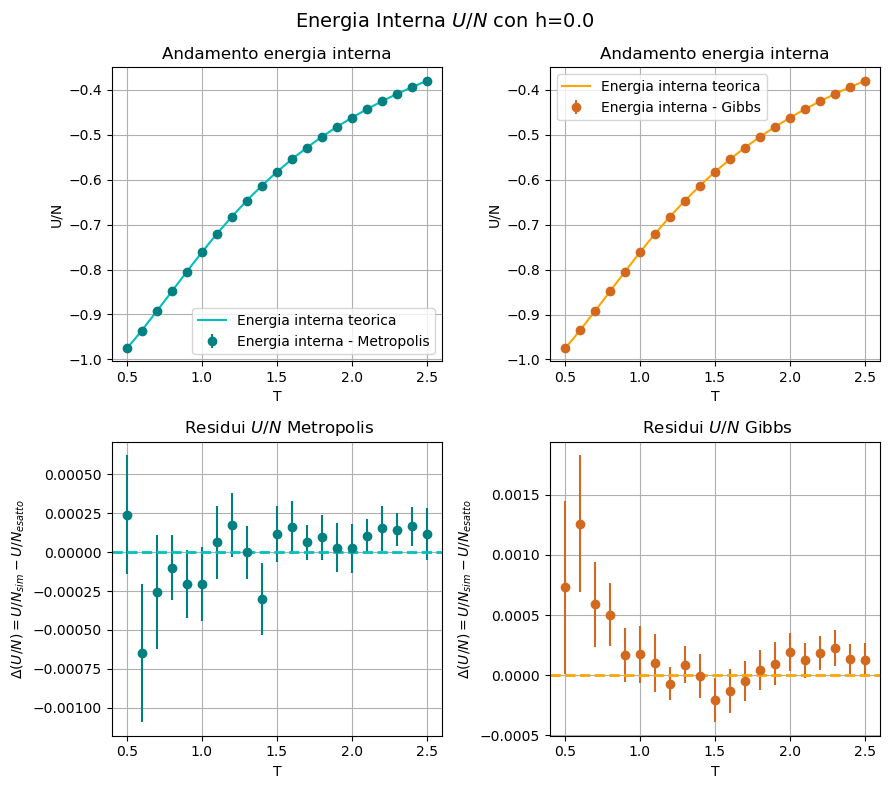

In [1]:
#energia interna

import numpy as np
import matplotlib.pyplot as plt

points=100
J = 1.0
Ns = 50

T = np.linspace(0.5,2.5,num=points)
beta = 1/T
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

N=21
temp = np.arange(N)
tenergy_M_prog = np.zeros(N)
tenergy_M_err_prog = np.zeros(N)

dati_metro=np.loadtxt("Esercizio6.1/OUTPUT/tenergy_temp_metro.dat")
temp=dati_metro[:,0]
tenergy_M_prog=dati_metro[:,1]
tenergy_M_err_prog=dati_metro[:,2]


tenergy_G_prog = np.zeros(N)
tenergy_G_err_prog = np.zeros(N)

dati_gibbs=np.loadtxt("Esercizio6.1/OUTPUT/tenergy_temp_gibbs.dat")
tenergy_G_prog=dati_gibbs[:,1]
tenergy_G_err_prog=dati_gibbs[:,2]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Energia Interna $U/N$ con h=0.0', fontsize=14)

ax1.plot(T,  e,color='c', label="Energia interna teorica")
ax1.errorbar(temp, tenergy_M_prog, yerr=tenergy_M_err_prog, fmt='o', color='teal', ecolor='teal', label="Energia interna - Metropolis")
ax1.grid(True)
ax1.set_xlabel('T')
ax1.set_ylabel('U/N')
ax1.set_title('Andamento energia interna')
ax1.legend()

ax2.plot(T,  e,color='orange', label="Energia interna teorica")
ax2.errorbar(temp, tenergy_G_prog, yerr=tenergy_G_err_prog, fmt='o', color='chocolate', ecolor='chocolate', label="Energia interna - Gibbs")
ax2.grid(True)
ax2.set_xlabel('T')
ax2.set_ylabel('U/N')
ax2.set_title('Andamento energia interna')
ax2.legend()

th = np.tanh(J/temp)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

ax3.errorbar(temp, (tenergy_M_prog-e), yerr=tenergy_M_err_prog, fmt='o', color='teal')
ax3.axhline(y=0, color='c', linestyle='--', linewidth=2)
ax3.grid(True)
ax3.set_xlabel('T')
ax3.set_ylabel('$\Delta (U/N) = U/N_{sim} - U/N_{esatto}$')
ax3.set_title(' Residui $U/N$ Metropolis')

ax4.errorbar(temp, (tenergy_G_prog-e), yerr=tenergy_G_err_prog, fmt='o', color='chocolate')
ax4.axhline(y=0, color='orange', linestyle='--', linewidth=2)
ax4.grid(True)
ax4.set_xlabel('T')
ax4.set_ylabel('$\Delta (U/N) = U/N_{sim} - U/N_{esatto}$')
ax4.set_title(' Residui $U/N$ Gibbs')

plt.tight_layout()
plt.show()

Nei seguenti grafici sono riportati i dati ottenuti per il calore spefico $C$ e i relativi errori.

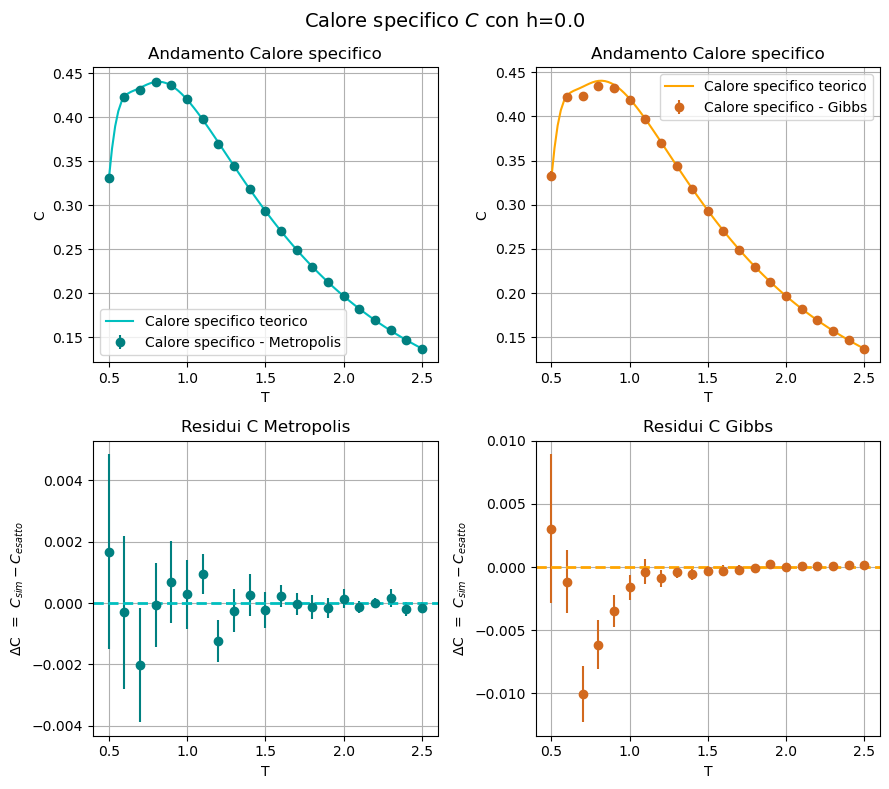

In [6]:
#calore specifico
cv_M_prog = np.zeros(N)
cv_M_err_prog = np.zeros(N)

dati_metro=np.loadtxt("Esercizio6.1/OUTPUT/cv_temp_metro.dat")
temp=dati_metro[:,0]
cv_M_prog=dati_metro[:,1]
cv_M_err_prog=dati_metro[:,2]


cv_G_prog = np.zeros(N)
cv_G_err_prog = np.zeros(N)

dati_gibbs=np.loadtxt("Esercizio6.1/OUTPUT/cv_temp_gibbs.dat")
cv_G_prog=dati_gibbs[:,1]
cv_G_err_prog=dati_gibbs[:,2]

T = np.linspace(0.5,2.5,num=points)
beta = 1/T
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Calore specifico $C$ con h=0.0', fontsize=14)

ax1.plot(T, heat ,color='c', label="Calore specifico teorico")
ax1.errorbar(temp, cv_M_prog, yerr=cv_M_err_prog, fmt='o', color='teal', ecolor='teal', label="Calore specifico - Metropolis")
ax1.grid(True)
ax1.set_xlabel('T')
ax1.set_ylabel('C')
ax1.set_title('Andamento Calore specifico')
ax1.legend()

ax2.plot(T, heat ,color='orange', label="Calore specifico teorico")
ax2.errorbar(temp, cv_G_prog, yerr=cv_G_err_prog, fmt='o', color='chocolate', ecolor='chocolate', label="Calore specifico - Gibbs")
ax2.grid(True)
ax2.set_xlabel('T')
ax2.set_ylabel('C')
ax2.set_title('Andamento Calore specifico')
ax2.legend()

beta=1/temp
th = np.tanh(J/temp)
thN= th**Ns
ch = 1/th
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

ax3.errorbar(temp, (cv_M_prog-heat), yerr=cv_M_err_prog, fmt='o', color='teal')
ax3.axhline(y=0, color='c', linestyle='--', linewidth=2)
ax3.grid(True)
ax3.set_xlabel('T')
ax3.set_ylabel('ΔC  =  $C_{sim} − C_{esatto}$')
ax3.set_title('Residui C Metropolis')


ax4.errorbar(temp, (cv_G_prog-heat), yerr= cv_G_err_prog,fmt='o', color='chocolate')
ax4.axhline(y=0, color='orange', linestyle='--', linewidth=2)
ax4.grid(True)
ax4.set_xlabel('T')
ax4.set_ylabel('ΔC  =  $C_{sim} − C_{esatto}$')
ax4.set_title('Residui C Gibbs')


plt.tight_layout()
plt.show()

Nei seguenti grafici sono riportati i dati ottenuti per la suscettibilità magnetica $\chi$ e i relativi errori.

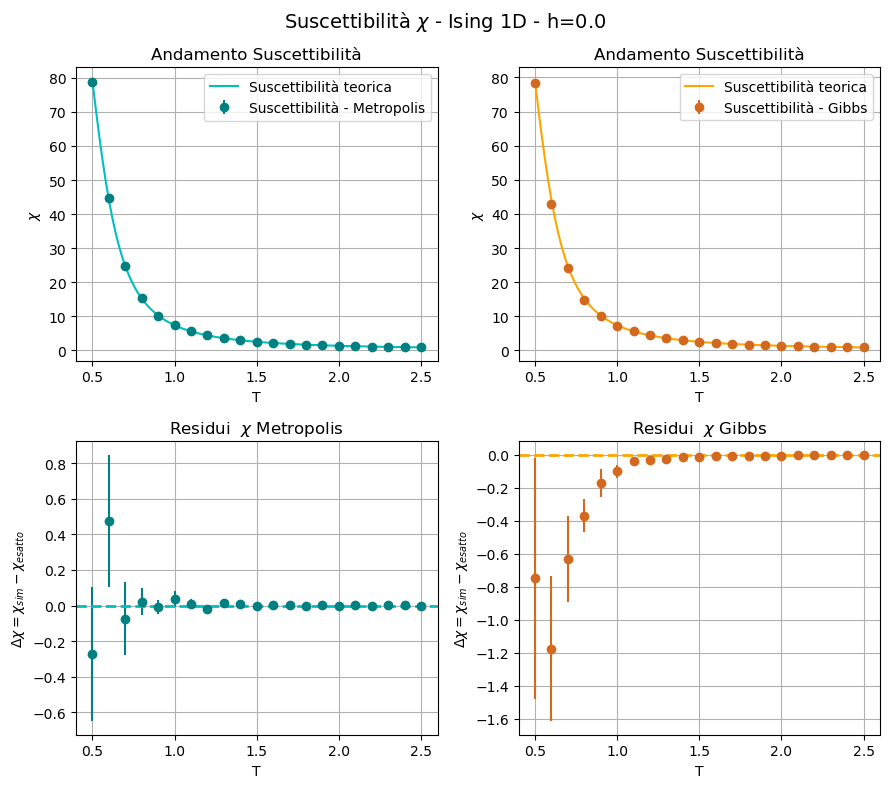

In [3]:
#suscettibilità chi
chi_M_prog = np.zeros(N)
chi_M_err_prog = np.zeros(N)

dati_metro=np.loadtxt("Esercizio6.1/OUTPUT/chi_temp_metro.dat")
chi_M_prog=dati_metro[:,1]
chi_M_err_prog=dati_metro[:,2]


chi_G_prog = np.zeros(N)
chi_G_err_prog = np.zeros(N)

dati_gibbs=np.loadtxt("Esercizio6.1/OUTPUT/chi_temp_gibbs.dat")
chi_G_prog=dati_gibbs[:,1]
chi_G_err_prog=dati_gibbs[:,2]


T = np.linspace(0.5,2.5,num=points)
beta = 1/T
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Suscettibilità $\chi$ - Ising 1D - h=0.0', fontsize=14)

ax1.plot(T,  X,color='c', label="Suscettibilità teorica")
ax1.errorbar(temp, chi_M_prog, yerr=chi_M_err_prog, fmt='o', color='teal', ecolor='teal', label="Suscettibilità - Metropolis")
ax1.grid(True)
ax1.set_xlabel('T')
ax1.set_ylabel('$\chi$')
ax1.set_title('Andamento Suscettibilità')
ax1.legend()

ax2.plot(T,  X,color='orange', label="Suscettibilità teorica")
ax2.errorbar(temp, chi_G_prog, yerr=chi_G_err_prog, fmt='o', color='chocolate', ecolor='chocolate', label="Suscettibilità - Gibbs")
ax2.grid(True)
ax2.set_xlabel('T')
ax2.set_ylabel('$\chi$')
ax2.set_title('Andamento Suscettibilità')
ax2.legend()

beta=1/temp
th = np.tanh(J/temp)
thN= th**Ns
ch = 1/th
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

ax3.errorbar(temp, (chi_M_prog -X), yerr=  chi_M_err_prog, color='teal', fmt='o')
ax3.axhline(y=0, color='c', linestyle='--', linewidth=2)
ax3.grid(True)
ax3.set_xlabel('T')
ax3.set_ylabel('$\Delta\chi  =  \chi_{sim} − \chi_{esatto}$')
ax3.set_title('Residui  $\chi$ Metropolis')

ax4.errorbar(temp, (chi_G_prog-X), yerr= chi_G_err_prog, color='chocolate', fmt='o')
ax4.axhline(y=0, color='orange', linestyle='--', linewidth=2)
ax4.grid(True)
ax4.set_xlabel('T')
ax4.set_ylabel('$\Delta\chi  =  \chi_{sim} − \chi_{esatto}$')
ax4.set_title('Residui  $\chi$ Gibbs')

plt.tight_layout()
plt.show()

Nei seguenti grafici sono riportati i dati ottenuti per la magnetizzazione $M$ e i relativi errori.

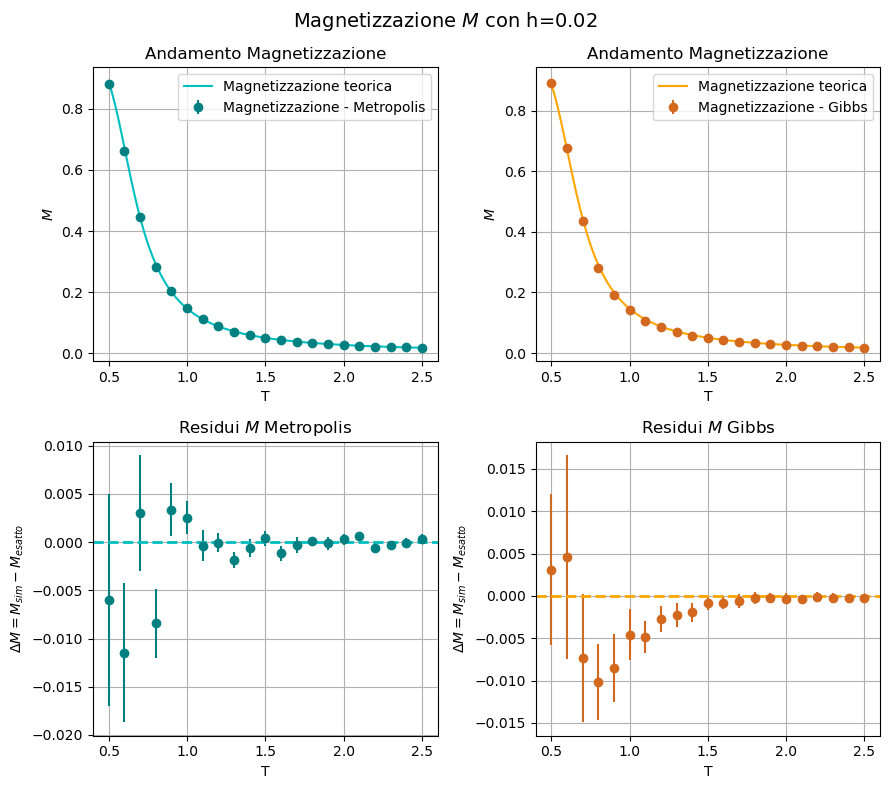

In [4]:
#magnetizzazione
magn_M_prog = np.zeros(N)
magn_M_err_prog = np.zeros(N)

dati_metro=np.loadtxt("Esercizio6.1/OUTPUT/magn_temp_metro.dat")
magn_M_prog=dati_metro[:,1]
magn_M_err_prog=dati_metro[:,2]


magn_G_prog = np.zeros(N)
magn_G_err_prog = np.zeros(N)

dati_gibbs=np.loadtxt("Esercizio6.1/OUTPUT/magn_temp_gibbs.dat")
magn_G_prog=dati_gibbs[:,1]
magn_G_err_prog=dati_gibbs[:,2]


h=0.02 #external field
T = np.linspace(0.5,2.5,num=points)
b = 1/T
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Magnetizzazione $M$ con h=0.02', fontsize=14)

ax1.plot(T,  M,color='c', label="Magnetizzazione teorica")
ax1.errorbar(temp, magn_M_prog, yerr=magn_M_err_prog, fmt='o', color='teal', ecolor='teal', label="Magnetizzazione - Metropolis")
ax1.grid(True)
ax1.set_xlabel('T')
ax1.set_ylabel('$M$')
ax1.set_title('Andamento Magnetizzazione')
ax1.legend()

ax2.plot(T,  M,color='orange', label="Magnetizzazione teorica")
ax2.errorbar(temp, magn_G_prog, yerr=magn_G_err_prog, fmt='o', color='chocolate', ecolor='chocolate', label="Magnetizzazione - Gibbs")
ax2.grid(True)
ax2.set_xlabel('T')
ax2.set_ylabel('$M$')
ax2.set_title('Andamento Magnetizzazione')
ax2.legend()

T = temp
b = 1/T
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)


ax3.errorbar(temp, (magn_M_prog-M), yerr=magn_M_err_prog, color='teal', fmt='o')
ax3.axhline(y=0, color='c', linestyle='--', linewidth=2)
ax3.grid(True)
ax3.set_xlabel('T')
ax3.set_ylabel('$\Delta M  =  M_{sim} − M_{esatto}$')
ax3.set_title('Residui $M$ Metropolis')

ax4.errorbar(temp, (magn_G_prog -M), yerr=magn_G_err_prog, color='chocolate', fmt='o')
ax4.axhline(y=0, color='orange', linestyle='--', linewidth=2)
ax4.grid(True)
ax4.set_xlabel('T')
ax4.set_ylabel('$\Delta M  =  M_{sim} − M_{esatto}$')
ax4.set_title('Residui $M$ Gibbs')

plt.tight_layout()
plt.show()

Per tutte le grandezze fisiche considerate c'è un'ottima corrispondenza tra i valori simulati e l'andamento teorico: sia per Metropolis che per Gibbs la grande maggioranza dei punti è compatibile entro 1$\sigma$ e il restante entro 2–3$\sigma$. Le compatibilità minori si osservano soprattutto a basse temperature e per Gibbs, il che evidenzia la maggiore difficoltà di esplorazione dello spazio delle configurazioni in questo regime. Infatti a bassa $T$ il sistema tende a rimanere in configurazioni di energia minima, rendendo più raro il campionamento di stati eccitati, e quindi gli errori risultano sottostimati.